## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
import os

# Method 1: Add the STAligner-master directory to Python path
# This notebook is in Tutorials/, so parent directory is STAligner-master
staligner_root = r'E:\yan0\multi-sample-disentangle\baseline\STAligner-master\STAligner-master'
if os.path.exists(staligner_root) and staligner_root not in sys.path:
    sys.path.insert(0, staligner_root)

import STAligner

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg

import torch
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Load Data

In [16]:
# ============================================================================
# Read CODEX CSV and Convert to AnnData (with coordinates)
# ============================================================================

import pandas as pd
import numpy as np
from anndata import AnnData
import scanpy as sc

# 文件路径
file_path = r'E:/yan0/multi-sample-disentangle/multi-sample-data/CODEX/CRC_clusters_neighborhoods_markers.csv'

print("Reading CSV file...")
df = pd.read_csv(file_path, low_memory=False)
print(f"  Loaded {len(df)} cells/spots")
print(f"  Total columns: {len(df.columns)}")

# 坐标列（主要坐标）
coord_cols = ['X:X', 'Y:Y']
if 'Z:Z' in df.columns:
    coord_cols.append('Z:Z')

# 细胞类型注释列
cell_type_cols = ['ClusterID', 'ClusterName']
if 'ClusterID' not in df.columns:
    cell_type_cols = [col for col in df.columns if 'cluster' in col.lower()]

# 邻域列
neighborhood_cols = ['neighborhood10', 'neighborhood number final', 'neighborhood name']

# 表达谱列（所有marker，以 'Cyc_' 开头的列）
expression_cols = []
for col in df.columns:
    if ':Cyc_' in col or 'Cyc_' in col:
        # 检查是否为数值列
        if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
            expression_cols.append(col)

# 如果没找到，尝试其他方式识别marker列
if len(expression_cols) == 0:
    # 查找包含marker名称的列（如 CD44, FOXP3 等）
    marker_keywords = ['CD', 'FOXP3', 'p53', 'GATA3', 'HLA-DR', 'PD-L1', 'Ki67', 
                      'MUC-1', 'Vimentin', 'Cytokeratin', 'EGFR', 'CDX2']
    for col in df.columns:
        if any(keyword in col for keyword in marker_keywords):
            if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
                if col not in coord_cols:
                    expression_cols.append(col)

print(f"\nDetected columns:")
print(f"  Coordinates: {coord_cols}")
print(f"  Cell types: {cell_type_cols}")
print(f"  Neighborhoods: {neighborhood_cols}")
print(f"  Expression markers: {len(expression_cols)} markers")

# 创建AnnData对象
# 表达矩阵
if len(expression_cols) > 0:
    X = df[expression_cols].values.astype(np.float32)
    var_names = expression_cols
else:
    raise ValueError("No expression columns found!")

# 创建AnnData
adata = AnnData(X)
adata.var_names = var_names
adata.obs_names = df['CellID'].values if 'CellID' in df.columns else [f"cell_{i}" for i in range(len(df))]

# 添加坐标信息到 obsm['spatial']
if 'X:X' in df.columns and 'Y:Y' in df.columns:
    spatial_coords = df[['X:X', 'Y:Y']].values.astype(np.float32)
    adata.obsm['spatial'] = spatial_coords
    print(f"\n  ✓ Added spatial coordinates (X, Y) to adata.obsm['spatial']")
    
    # 如果有Z坐标，也添加
    if 'Z:Z' in df.columns:
        adata.obsm['spatial_3d'] = df[['X:X', 'Y:Y', 'Z:Z']].values.astype(np.float32)
        print(f"  ✓ Added 3D coordinates (X, Y, Z) to adata.obsm['spatial_3d']")
    
    # 瓦片内坐标（可选）
    if 'X_withinTile:X_withinTile' in df.columns and 'Y_withinTile:Y_withinTile' in df.columns:
        adata.obsm['spatial_within_tile'] = df[['X_withinTile:X_withinTile', 'Y_withinTile:Y_withinTile']].values.astype(np.float32)
        print(f"  ✓ Added within-tile coordinates to adata.obsm['spatial_within_tile']")

# 添加细胞类型注释到obs
for col in cell_type_cols:
    if col in df.columns:
        adata.obs[col] = df[col].values
        print(f"  ✓ Added {col} to adata.obs")

# 添加邻域信息到obs
for col in neighborhood_cols:
    if col in df.columns:
        adata.obs[col] = df[col].values
        print(f"  ✓ Added {col} to adata.obs")

# 添加其他重要元数据到obs
metadata_cols = ['EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 
                 'groups', 'patients', 'spots', 'ClusterSize']
for col in metadata_cols:
    if col in df.columns:
        adata.obs[col] = df[col].values
        print(f"  ✓ Added {col} to adata.obs")

# 添加组合marker列（如 CD4+ICOS+ 等）到obs（如果存在）
combo_markers = [col for col in df.columns if '+' in col and col not in expression_cols]
for col in combo_markers[:10]:  # 只添加前10个
    if col in df.columns:
        adata.obs[col] = df[col].values

print(f"\n✓ AnnData created successfully!")
print(f"  Shape: {adata.shape}")
print(f"  Observations (cells): {adata.n_obs}")
print(f"  Variables (markers): {adata.n_vars}")
print(f"\n  adata.obs columns ({len(adata.obs.columns)}): {list(adata.obs.columns)}")
print(f"  adata.obsm keys: {list(adata.obsm.keys())}")

# 显示前几行数据预览
print(f"\nFirst few rows of adata.obs:")
print(adata.obs[['ClusterID', 'ClusterName', 'neighborhood name']].head() if 'ClusterName' in adata.obs.columns else adata.obs.head())

# 显示表达矩阵统计
print(f"\nExpression matrix statistics:")
print(f"  Min: {X.min():.2f}, Max: {X.max():.2f}, Mean: {X.mean():.2f}, Std: {X.std():.2f}")

# 显示坐标范围
if 'spatial' in adata.obsm:
    coords = adata.obsm['spatial']
    print(f"\nSpatial coordinates range:")
    print(f"  X: [{coords[:, 0].min():.2f}, {coords[:, 0].max():.2f}]")
    print(f"  Y: [{coords[:, 1].min():.2f}, {coords[:, 1].max():.2f}]")

Reading CSV file...
  Loaded 258385 cells/spots
  Total columns: 99

Detected columns:
  Coordinates: ['X:X', 'Y:Y', 'Z:Z']
  Cell types: ['ClusterID', 'ClusterName']
  Neighborhoods: ['neighborhood10', 'neighborhood number final', 'neighborhood name']
  Expression markers: 58 markers

  ✓ Added spatial coordinates (X, Y) to adata.obsm['spatial']
  ✓ Added 3D coordinates (X, Y, Z) to adata.obsm['spatial_3d']
  ✓ Added within-tile coordinates to adata.obsm['spatial_within_tile']
  ✓ Added ClusterID to adata.obs
  ✓ Added ClusterName to adata.obs
  ✓ Added neighborhood10 to adata.obs
  ✓ Added neighborhood number final to adata.obs
  ✓ Added neighborhood name to adata.obs
  ✓ Added EventID to adata.obs
  ✓ Added File Name to adata.obs
  ✓ Added Region to adata.obs
  ✓ Added TMA_AB to adata.obs
  ✓ Added TMA_12 to adata.obs
  ✓ Added groups to adata.obs
  ✓ Added patients to adata.obs
  ✓ Added spots to adata.obs
  ✓ Added ClusterSize to adata.obs

✓ AnnData created successfully!
  Shape:

In [17]:
Batch_list = []
adj_list = []

------Calculating spatial graph...
The graph contains 33358 edges, 3726 cells.
8.9528 neighbors per cell on average.


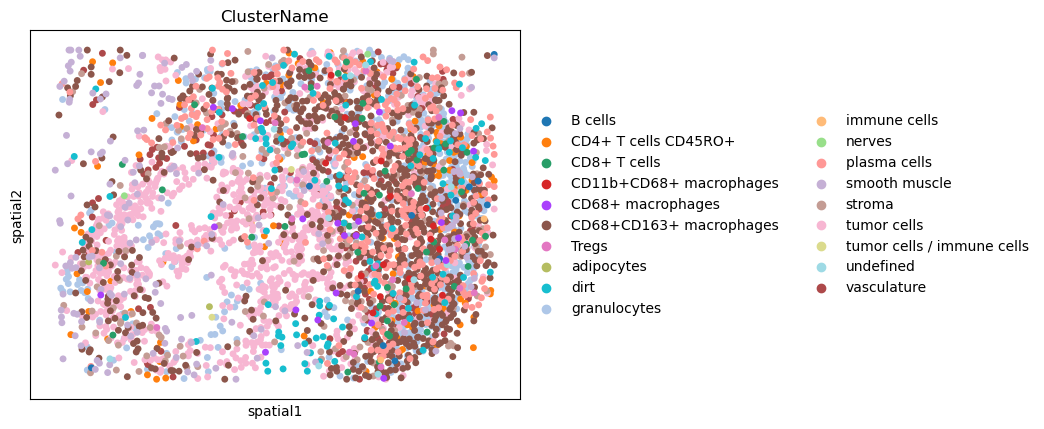

In [18]:
adata1 = adata[adata.obs['patients']==4]
adata2 = adata1[adata1.obsm['spatial_3d'][:,2]==8]
adata2
sc.pl.spatial(adata2, img_key="hires", color=["ClusterName"], spot_size=30, show=False)
sc.pp.filter_genes(adata2, min_cells=50)

# Normalization
sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)

adata2 = adata2[:, adata2.var['highly_variable']]
adata2.obs['Ground Truth'] = adata2.obs['ClusterName'].astype('category')

# Constructing the spatial network
STAligner.Cal_Spatial_Net(adata2, rad_cutoff=40) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating spatial graph...
The graph contains 20682 edges, 2993 cells.
6.9101 neighbors per cell on average.


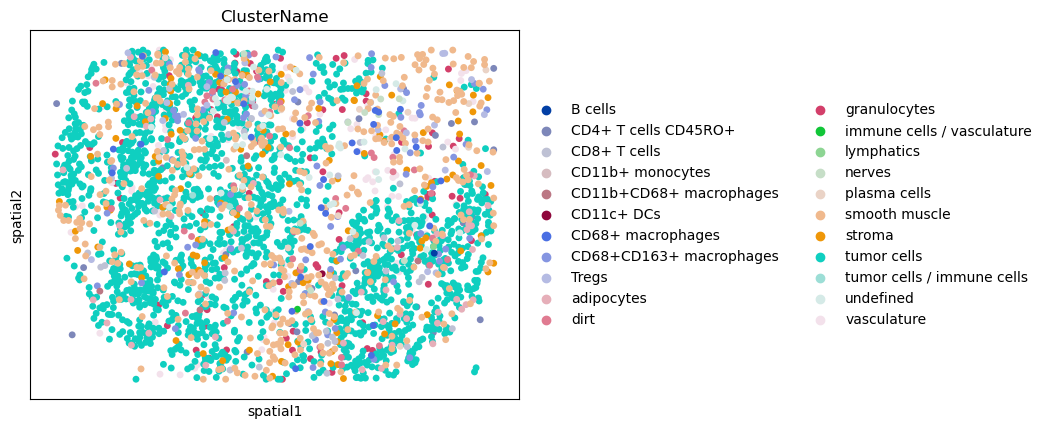

In [19]:
adata1 = adata[adata.obs['patients']==21]
# adata1
adata2 = adata1[adata1.obsm['spatial_3d'][:,2]==7]
sc.pl.spatial(adata2, img_key="hires", color=["ClusterName"], spot_size=30, show=False)
sc.pp.filter_genes(adata2, min_cells=50)

# Normalization
sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)

adata2 = adata2[:, adata2.var['highly_variable']]
adata2.obs['Ground Truth'] = adata2.obs['ClusterName'].astype('category')

# Constructing the spatial network
STAligner.Cal_Spatial_Net(adata2, rad_cutoff=40) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating spatial graph...
The graph contains 15046 edges, 2490 cells.
6.0426 neighbors per cell on average.


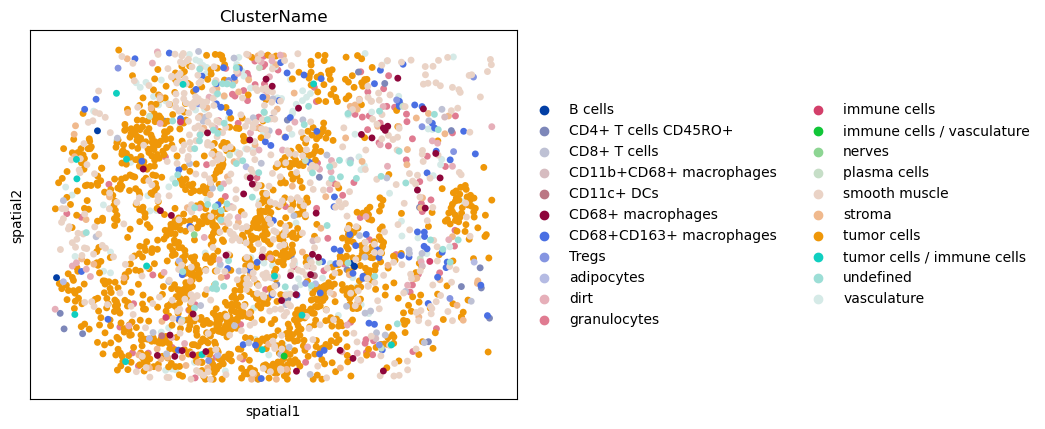

In [20]:
adata1 = adata[adata.obs['patients']==21]
# adata1
adata2 = adata1[adata1.obsm['spatial_3d'][:,2]==8]
sc.pl.spatial(adata2, img_key="hires", color=["ClusterName"], spot_size=30, show=False)
sc.pp.filter_genes(adata2, min_cells=50)

# Normalization
sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)

adata2 = adata2[:, adata2.var['highly_variable']]
adata2.obs['Ground Truth'] = adata2.obs['ClusterName'].astype('category')

# Constructing the spatial network
STAligner.Cal_Spatial_Net(adata2, rad_cutoff=40) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

In [21]:
section_ids = [str(i+1) for i in range(len(Batch_list))]

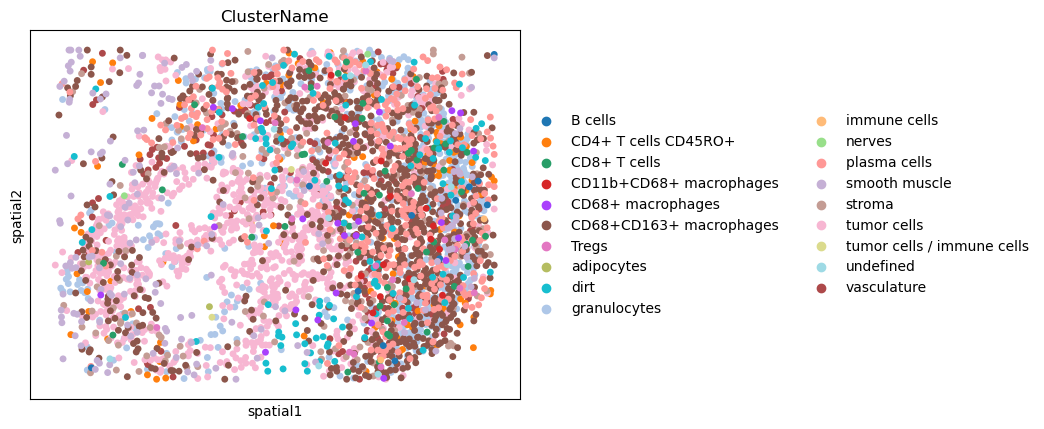

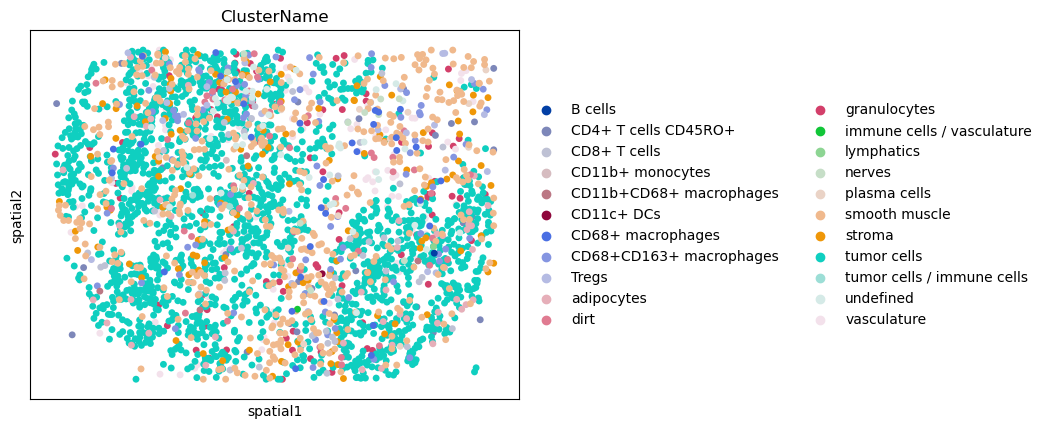

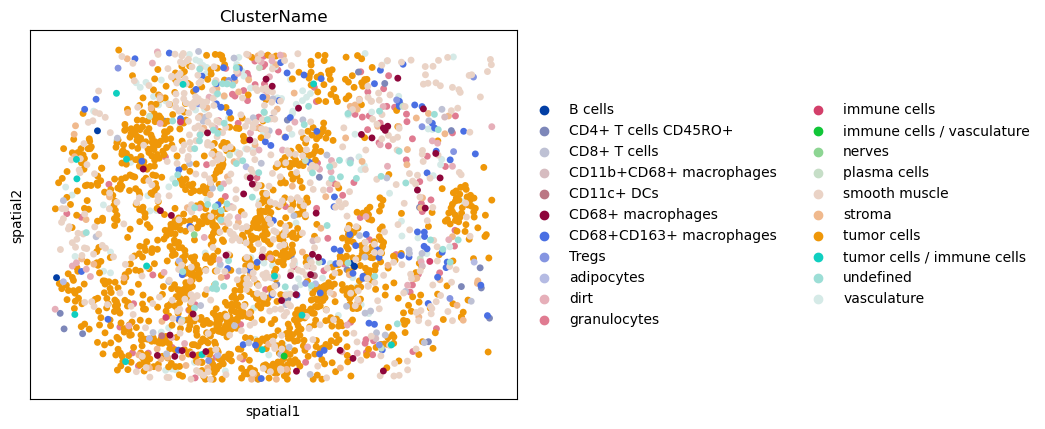

In [22]:
for adata in Batch_list:
    sc.pl.spatial(adata, img_key="hires", color=["ClusterName"], spot_size=30, show=False)

## Concat the scanpy objects for multiple slices

In [23]:
Batch_list

[AnnData object with n_obs × n_vars = 3726 × 58
     obs: 'ClusterID', 'ClusterName', 'neighborhood10', 'neighborhood number final', 'neighborhood name', 'EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 'groups', 'patients', 'spots', 'ClusterSize', 'CD4+ICOS+', 'CD4+Ki67+', 'CD4+PD-1+', 'CD68+CD163+ICOS+', 'CD68+CD163+Ki67+', 'CD68+CD163+PD-1+', 'CD68+ICOS+', 'CD68+Ki67+', 'CD68+PD-1+', 'CD8+ICOS+', 'Ground Truth'
     var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'ClusterName_colors', 'hvg', 'log1p', 'Spatial_Net', 'adj'
     obsm: 'spatial', 'spatial_3d', 'spatial_within_tile',
 AnnData object with n_obs × n_vars = 2993 × 58
     obs: 'ClusterID', 'ClusterName', 'neighborhood10', 'neighborhood number final', 'neighborhood name', 'EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 'groups', 'patients', 'spots', 'ClusterSize', 'CD4+ICOS+', 'CD4+Ki67+', 'CD4+PD-1+', 'CD68+CD163+ICOS+', 'CD68+CD163+Ki67+', 'CD68+CD163+P

In [24]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (9209, 58)


## Concat the spatial network for multiple slices

In [25]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(section_ids)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

## Running STAligner

In [26]:
%%time
adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh = 50, device=used_device)

STAligner(
  (conv1): GATConv(58, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 58, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [00:14<00:00, 34.91it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


...

Update spot triplets at epoch 800


 79%|███████▉  | 397/500 [00:16<00:03, 34.15it/s]

Update spot triplets at epoch 900


100%|██████████| 500/500 [00:20<00:00, 24.64it/s]

CPU times: total: 31.3 s
Wall time: 35 s


In [27]:
adata_concat

AnnData object with n_obs × n_vars = 9209 × 58
    obs: 'ClusterID', 'ClusterName', 'neighborhood10', 'neighborhood number final', 'neighborhood name', 'EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 'groups', 'patients', 'spots', 'ClusterSize', 'CD4+ICOS+', 'CD4+Ki67+', 'CD4+PD-1+', 'CD68+CD163+ICOS+', 'CD68+CD163+Ki67+', 'CD68+CD163+PD-1+', 'CD68+ICOS+', 'CD68+Ki67+', 'CD68+PD-1+', 'CD8+ICOS+', 'Ground Truth', 'slice_name', 'batch_name'
    uns: 'edgeList'
    obsm: 'spatial', 'spatial_3d', 'spatial_within_tile', 'STAGATE', 'STAligner'

## Clustering

In [30]:
STAligner.mclust_R(adata_concat, num_cluster=6, used_obsm='STAligner')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

from sklearn.metrics import adjusted_rand_score as ari_score
print('mclust, ARI = %01.3f' % ari_score(adata_concat.obs['Ground Truth'], adata_concat.obs['mclust']))

fitting ...
  |======================================================================| 100%
mclust, ARI = 0.279


## Visualization

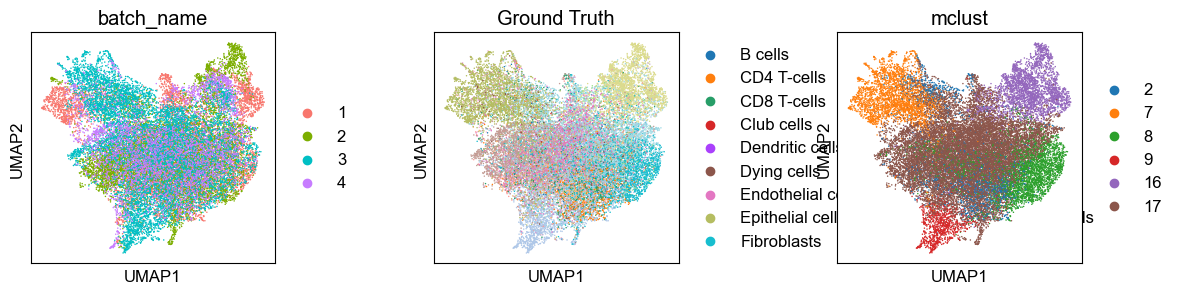

In [25]:
sc.pp.neighbors(adata_concat, use_rep='STAligner', random_state=666)
sc.tl.umap(adata_concat, random_state=666)

section_color = ['#f8766d', '#7cae00', '#00bfc4', '#c77cff']
section_color_dict = dict(zip(section_ids, section_color))
adata_concat.uns['batch_name_colors'] = [section_color_dict[x] for x in adata_concat.obs.batch_name.cat.categories]
adata_concat.obs['mclust'] = pd.Series(STAligner.match_cluster_labels(adata_concat.obs['Ground Truth'], adata_concat.obs['mclust'].values),
                                         index=adata_concat.obs.index, dtype='category')

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams['font.size'] = 12

sc.pl.umap(adata_concat, color=['batch_name', 'Ground Truth', 'mclust'], ncols=3, 
           wspace=0.5, show=True)

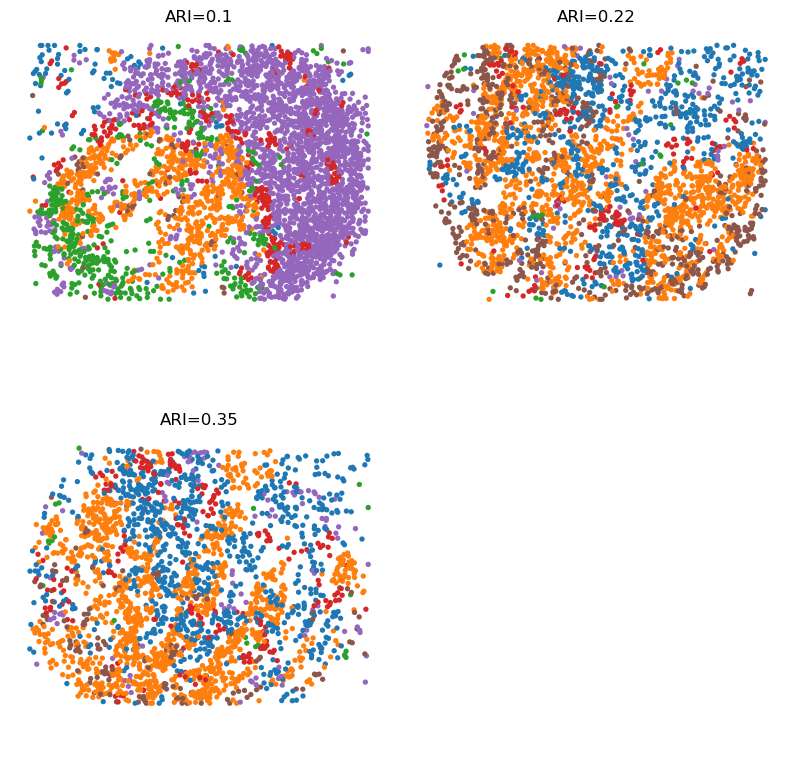

In [32]:
Batch_list1 = []
for section_id in section_ids:
    Batch_list1.append(adata_concat[adata_concat.obs['batch_name'] == section_id])
from sklearn.metrics import adjusted_rand_score as ari_score
import math

import matplotlib.pyplot as plt
spot_size = 30
title_size = 12

# 根据实际数量计算ARI
n_batches = len(Batch_list1)
ARI_list = []
for bb in range(n_batches):
    ARI_list.append(round(ari_score(Batch_list1[bb].obs['Ground Truth'], Batch_list1[bb].obs['mclust']), 2))

# 计算子图布局：固定2列，行数根据数量计算
n_cols = 2
n_rows = math.ceil(n_batches / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})

# 确保axes是二维数组
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# 绘制每个batch
for bb in range(n_batches):
    row = bb // n_cols
    col = bb % n_cols
    ax = axes[row, col]
    
    _sc = sc.pl.spatial(Batch_list1[bb], img_key=None, color=['mclust'], title=[''],
                        legend_loc=None, legend_fontsize=12, show=False, ax=ax, frameon=False,
                        spot_size=spot_size)
    _sc[0].set_title("ARI=" + str(ARI_list[bb]), size=title_size)

# 隐藏多余的子图
for bb in range(n_batches, n_rows * n_cols):
    row = bb // n_cols
    col = bb % n_cols
    axes[row, col].axis('off')